In [1]:
# ---- Standard-library imports ----
import pathlib  # resolve the downloaded dataset path
import random
import subprocess
import sys

# ---- Dataset loader (installed automatically on first use if missing) ----
try:
    import kagglehub
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True
    )
    import kagglehub

# ---- Data handling & plotting ----
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# ---- scikit-learn: models, preprocessing, selection & evaluation ----
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    train_test_split,
)

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

# ---- Reproducible project seed ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Shared style so every chart looks the same (bold labels, 150 dpi).
plt.rcParams.update(
    {
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "figure.dpi": 150,
    }
)

# Same 3 colors used in all the plots below.
PALETTE = ["#EA2027", "#006266", "#1B1464"]

In [3]:
# 1. Load the Kaggle dataset (kagglehub downloads it for us).
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")
df = pd.read_csv(next(pathlib.Path(path).glob("*.csv")))
print(f"Shape: {df.shape}")
df.head()

Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
from sklearn.impute import KNNImputer

target_column = "diabetes"

# Encode categorical features (factorize maps missing categories to -1).
for col in df.select_dtypes(include=["object", "str"]).columns:
    df[col] = pd.factorize(df[col])[0]

# Treat -1 placeholders (from factorize) and any NaNs as missing, then impute
# via KNN instead of dropping rows outright.
df = df.replace(-1, np.nan)
imputer = KNNImputer(n_neighbors=5)
df[df.columns] = imputer.fit_transform(df)

# Remove near-constant columns.
near_constant = [
    c
    for c in df.columns
    if c != target_column and df[c].value_counts(normalize=True).iloc[0] > 0.99
]
print("Dropping near-constant columns:", near_constant)
df = df.drop(columns=near_constant)

Dropping near-constant columns: []


In [5]:
X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (80000, 8) | Test: (20000, 8)


In [6]:
from sklearn.feature_selection import RFE

# RFE needs coef_, which RBF-SVM doesn't have — use a linear-kernel SVM
# just for ranking features, then apply the selection to the real pipeline.
selector = RFE(
    estimator=SVC(
        kernel="linear",
        C=1.0,
        gamma="scale",
        random_state=SEED,
    ),
    n_features_to_select=5,
)
selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]
print("Selected features:", list(selected_features))

X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

Selected features: ['age', 'hypertension', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

# GridSearchCV on the full ~80k rows would be very slow for an RBF SVM —
# tune on a subsample, then refit the chosen params on the full training set.
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train), size=min(10000, len(X_train)), replace=False)

base_svm = CalibratedClassifierCV(
    SVC(kernel="rbf", class_weight="balanced", random_state=SEED),
    ensemble=False,
)
param_grid = {
    "estimator__C": [0.1, 1, 10],
    "estimator__gamma": ["scale", 0.01, 0.1],
}

grid_search = GridSearchCV(base_svm, param_grid, scoring="f1", cv=3, n_jobs=-1)
grid_search.fit(X_train[sample_idx], y_train.iloc[sample_idx])
print("Best SVM params:", grid_search.best_params_)

# Refit the best params on the full training set.
svm_model = grid_search.best_estimator_
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Gaussian Naive Bayes with balanced priors
nb_model = GaussianNB(priors=[0.5, 0.5])
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print("Training complete.")

Best SVM params: {'estimator__C': 10, 'estimator__gamma': 'scale'}
Training complete.


In [8]:
from sklearn.model_selection import cross_val_score

cv_f1_svm = cross_val_score(svm_model, X_train, y_train, cv=5, scoring="f1")
cv_f1_nb = cross_val_score(nb_model, X_train, y_train, cv=5, scoring="f1")

print(f"SVM  5-fold CV F1: {cv_f1_svm.mean():.4f} ± {cv_f1_svm.std():.4f}")
print(f"NB   5-fold CV F1: {cv_f1_nb.mean():.4f} ± {cv_f1_nb.std():.4f}")

SVM  5-fold CV F1: 0.7265 ± 0.0124
NB   5-fold CV F1: 0.5515 ± 0.0029


In [9]:
print("=" * 55)
print("SVM Classification Report")
print("=" * 55)
print(
    classification_report(
        y_test, y_pred_svm, digits=4, target_names=["No Diabetes", "Diabetes"]
    )
)

print("=" * 55)
print("Naive Bayes Classification Report")
print("=" * 55)
print(
    classification_report(
        y_test, y_pred_nb, digits=4, target_names=["No Diabetes", "Diabetes"]
    )
)

SVM Classification Report
              precision    recall  f1-score   support

 No Diabetes     0.9618    0.9999    0.9805     18300
    Diabetes     0.9990    0.5729    0.7282      1700

    accuracy                         0.9637     20000
   macro avg     0.9804    0.7864    0.8544     20000
weighted avg     0.9650    0.9637    0.9591     20000

Naive Bayes Classification Report
              precision    recall  f1-score   support

 No Diabetes     0.9797    0.8996    0.9379     18300
    Diabetes     0.4251    0.7994    0.5550      1700

    accuracy                         0.8911     20000
   macro avg     0.7024    0.8495    0.7465     20000
weighted avg     0.9326    0.8911    0.9054     20000



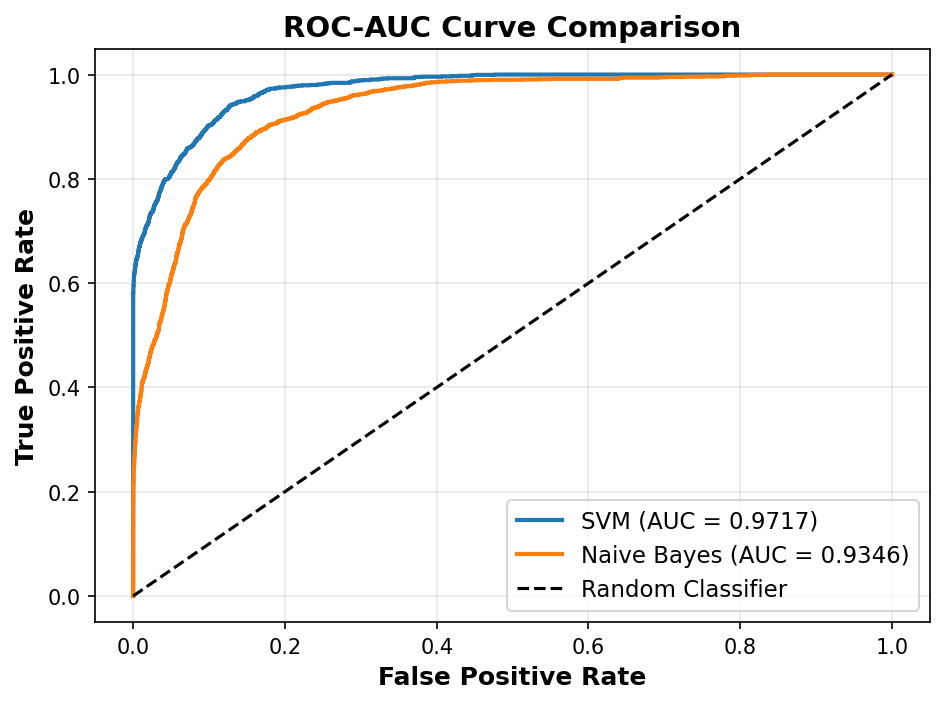

In [10]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.4f})", linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC-AUC Curve Comparison", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
results = pd.DataFrame(
    {
        "Model": ["SVM (RBF)", "Naive Bayes"],
        "Accuracy": [
            accuracy_score(y_test, y_pred_svm),
            accuracy_score(y_test, y_pred_nb),
        ],
        "Precision": [
            precision_score(y_test, y_pred_svm),
            precision_score(y_test, y_pred_nb),
        ],
        "Recall": [recall_score(y_test, y_pred_svm), recall_score(y_test, y_pred_nb)],
        "F1-Score": [f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_nb)],
        "ROC-AUC": [auc_svm, auc_nb],
    }
)

# Format to 4 decimal places
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM (RBF),0.9636,0.9990,0.5729,0.7282,0.9717
1,Naive Bayes,0.8910,0.4251,0.7994,0.5550,0.9346
